In [34]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from ultralytics.utils.downloads import download
from PIL import Image
import os

In [35]:
TRAIN_DATASET_DIR = "./datasets/VisDrone2019-DET-train"
VALIDATION_DATASET_DIR = "./datasets/VisDrone2019-DET-val"
TEST_CHALLENGE_DATASET_DIR = "./datasets/VisDrone2019-DET-test-challenge"
RUNS_DIR = "./runs"

yaml_file = TRAIN_DATASET_DIR + "/data.yaml"

In [36]:
DATASETS_ROOT = str(Path(TRAIN_DATASET_DIR).resolve().parent)

yaml_content = f"""path: {DATASETS_ROOT}
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-challenge/images
nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
"""

with open(yaml_file, 'w') as f:
    f.write(yaml_content)

In [37]:
download("https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt", dir=".")

In [38]:
def convert_visdrone_to_yolo(annotation_dir, images_dir, labels_output_dir):
    os.makedirs(labels_output_dir, exist_ok=True)
    converted = 0
    skipped = 0
    
    annotation_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith('.txt')])
    
    for ann_file in annotation_files:
        ann_path = os.path.join(annotation_dir, ann_file)
        img_file = ann_file.replace('.txt', '.jpg')
        img_path = os.path.join(images_dir, img_file)
        
        # Get image dimensions
        try:
            img = Image.open(img_path)
            img_w, img_h = img.size
        except Exception as e:
            print(f"Skipped {ann_file}, can't open image {e}")
            skipped += 1
            continue
        
        # Convert annotations
        yolo_lines = []
        try:
            with open(ann_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(',')
                    x_left = int(parts[0])
                    y_top = int(parts[1])
                    bbox_w = int(parts[2])
                    bbox_h = int(parts[3])
                    class_id = int(parts[4])
                    
                    # Convert to normalized center coordinates
                    # Apprently this is needed 
                    x_center = (x_left + bbox_w / 2) / img_w
                    y_center = (y_top + bbox_h / 2) / img_h
                    norm_w = bbox_w / img_w
                    norm_h = bbox_h / img_h
                    
                    x_center = max(0, min(1, x_center))
                    y_center = max(0, min(1, y_center))
                    norm_w = max(0, min(1, norm_w))
                    norm_h = max(0, min(1, norm_h))
                    
                    yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")
            
            # Write YOLO format labels to a seperate folder
            output_path = os.path.join(labels_output_dir, ann_file)
            with open(output_path, 'w') as f:
                f.writelines(yolo_lines)
            converted += 1
        except Exception as e:
            print(f"Error processing {ann_file}: {e}")
            skipped += 1
    
    return converted, skipped

# Convert training dataset
train_ann_dir = os.path.join(TRAIN_DATASET_DIR, "annotations")
train_img_dir = os.path.join(TRAIN_DATASET_DIR, "images")
train_labels_dir = os.path.join(TRAIN_DATASET_DIR, "labels")
converted_train, skipped_train = convert_visdrone_to_yolo(train_ann_dir, train_img_dir, train_labels_dir)

# Convert validation dataset
val_ann_dir = os.path.join(VALIDATION_DATASET_DIR, "annotations")
val_img_dir = os.path.join(VALIDATION_DATASET_DIR, "images")
val_labels_dir = os.path.join(VALIDATION_DATASET_DIR, "labels")
converted_val, skipped_val = convert_visdrone_to_yolo(val_ann_dir, val_img_dir, val_labels_dir)

print(f"Training: Converted {converted_train} files, Skipped {skipped_train}")
print(f"Validation: Converted {converted_val} files, Skipped {skipped_val}")


Training: Converted 6471 files, Skipped 0
Validation: Converted 548 files, Skipped 0


In [39]:
model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_file,
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    patience=5,
    save=True,
    project=RUNS_DIR,
    name="baseline_yolo11n",
    verbose=True,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/VisDrone2019-DET-train/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, mul

In [41]:
results_path = Path(RUNS_DIR) / "detect" / "runs" / "baseline_yolo11n2"

df = pd.read_csv(str(results_path / "results.csv"))
last_row = df.iloc[-1]

print(f"Epochs: {len(df)}")
print(f"Final Loss: {last_row['train/box_loss']:.4f}")
print(f"Final Val Loss: {last_row['val/box_loss']:.4f}")
print(f"mAP50: {last_row['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {last_row['metrics/mAP50-95(B)']:.4f}")
print(f"Precision: {last_row['metrics/precision(B)']:.4f}")
print(f"Recall: {last_row['metrics/recall(B)']:.4f}")

Epochs: 20
Final Loss: 1.4770
Final Val Loss: 1.5336
mAP50: 0.2891
mAP50-95: 0.1580
Precision: 0.3476
Recall: 0.2433


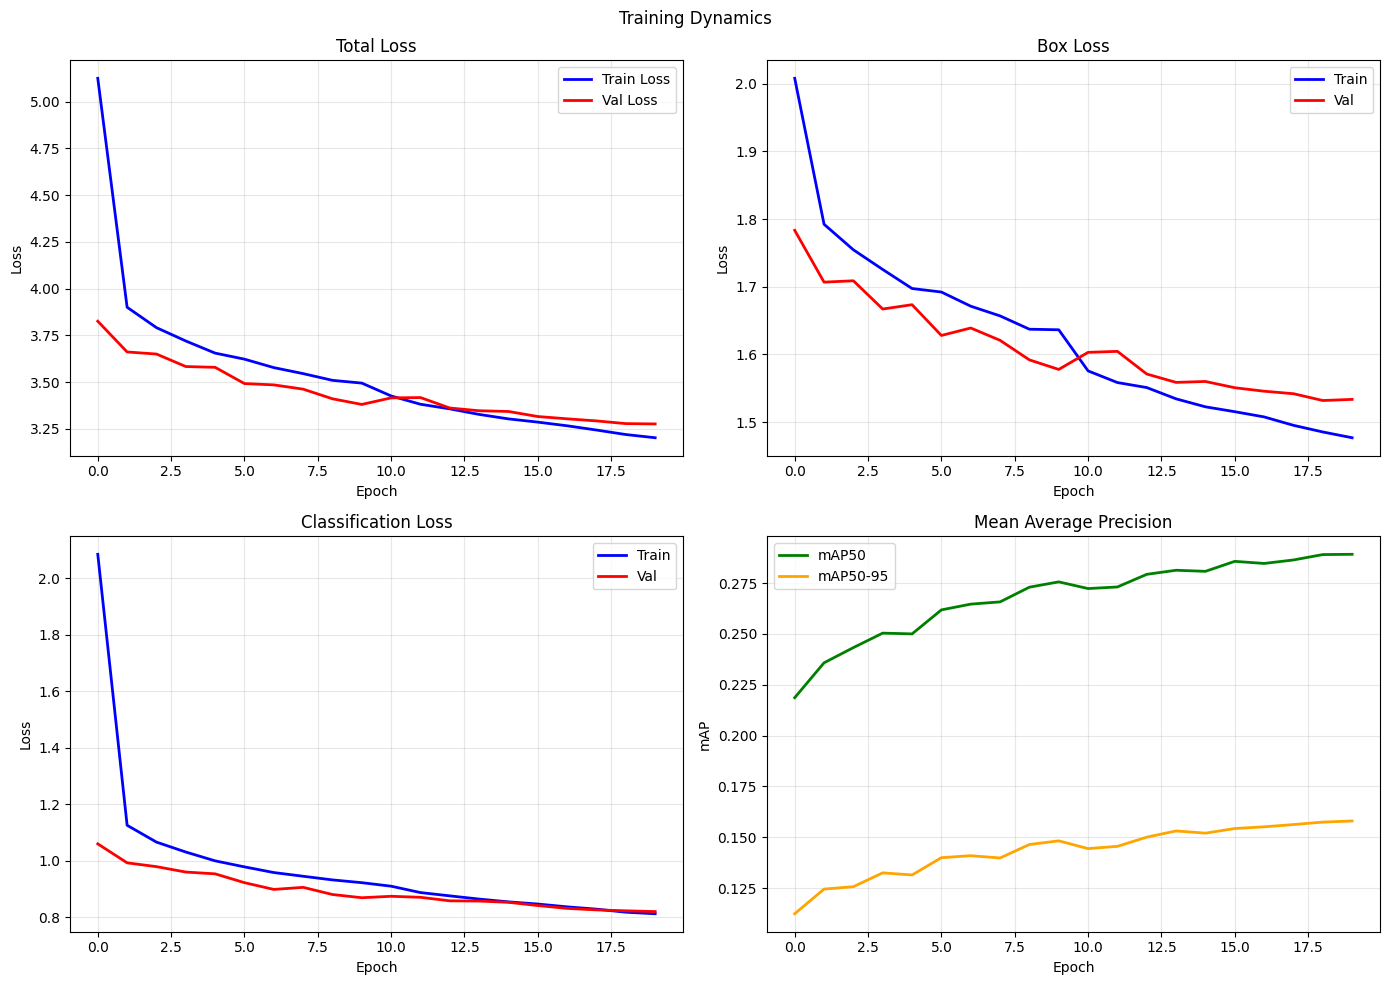

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Dynamics')

train_total = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_total   = df['val/box_loss']   + df['val/cls_loss']   + df['val/dfl_loss']

ax = axes[0, 0]
ax.plot(df.index, train_total, 'b-', label='Train Loss', linewidth=2)
ax.plot(df.index, val_total, 'r-', label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Total Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(df.index, df['train/box_loss'], 'b-', label='Train', linewidth=2)
ax.plot(df.index, df['val/box_loss'], 'r-', label='Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Box Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(df.index, df['train/cls_loss'], 'b-', label='Train', linewidth=2)
ax.plot(df.index, df['val/cls_loss'], 'r-', label='Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Classification Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(df.index, df['metrics/mAP50(B)'], 'g-', label='mAP50', linewidth=2)
ax.plot(df.index, df['metrics/mAP50-95(B)'], 'orange', label='mAP50-95', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('Mean Average Precision')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

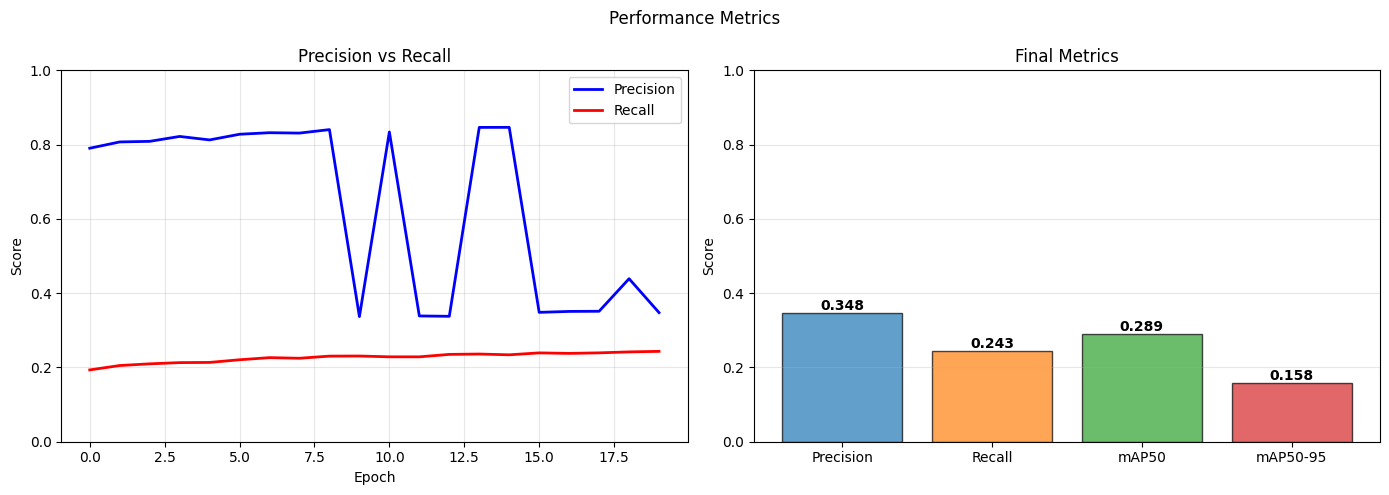

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Performance Metrics')

ax = axes[0]
ax.plot(df.index, df['metrics/precision(B)'], 'b-', label='Precision', linewidth=2)
ax.plot(df.index, df['metrics/recall(B)'], 'r-', label='Recall', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

ax = axes[1]
metrics_names = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
metrics_values = [
    last_row['metrics/precision(B)'],
    last_row['metrics/recall(B)'],
    last_row['metrics/mAP50(B)'],
    last_row['metrics/mAP50-95(B)']
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.3f}',
           ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Final Metrics')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [44]:
best_model_path = results_path / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

val_results = best_model.val(
    data=yaml_file,
    imgsz=640,
    device=0,
    verbose=False
)

print(f"Validation mAP50: {val_results.box.map50:.4f}")
print(f"Validation mAP50-95: {val_results.box.map:.4f}")
print(f"Validation Precision: {float(val_results.box.p.mean()):.4f}")
print(f"Validation Recall: {float(val_results.box.r.mean()):.4f}")

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4813.6±935.4 MB/s, size: 153.1 KB)
val: Scanning /home/musab/Documents/ml-models/model-comparisons/datasets/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 135.2Mit/s 0.0s
val: /home/musab/Documents/ml-models/model-comparisons/datasets/VisDrone2019-DET-val/images/0000271_01201_d_0000379.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 10.4it/s 3.4s0.1s
                   all        548      40168      0.348      0.243      0.289      0.158
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /home/musab/Documents/ml-models/model-comparisons/runs/detect/val
Vali